In [2]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [3]:
data_path = '40Sen_30Sec_stomping_30sec_quiet.csv' 
data = pd.read_csv(data_path)
distances =  pd.read_csv('dist.csv')
print("Data shape:", data.shape)
print("First few rows:")
print(data.head())
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Data shape: (59999, 40)
First few rows:
    -0.0301  -0.00059605  -0.0044703  -0.0056624  -0.0083447  -0.0011921  \
0 -0.046492     0.003278   -0.005960   -0.009537   -0.008047    0.002980   
1 -0.059307     0.000000    0.001192   -0.008047   -0.006259   -0.000596   
2 -0.056624    -0.001192    0.008941    0.000596   -0.000596   -0.003874   
3 -0.039339    -0.000298    0.012815   -0.004470    0.001490   -0.001788   
4 -0.021160    -0.001192    0.013411   -0.012517   -0.001192    0.002384   

   -0.011623  -0.00089407  -0.00059605.1  -0.0098348  ...  0.0074506  \
0  -0.018775    -0.000894      -0.004470   -0.008345  ...   0.037849   
1  -0.014007     0.002682      -0.004470   -0.005960  ...   0.032187   
2  -0.005662     0.004172      -0.005662   -0.002682  ...   0.006259   
3   0.005662     0.005066      -0.008941    0.003278  ...  -0.032783   
4   0.014007     0.004172      -0.006556    0.006855  ...  -0.054836   

   0.010729  0.00029802  -0.0074506  -0.022352  0.068545  -0.010133  \

```markdown
### Data Preparation

In this notebook, we are working with audio data to distinguish between quiet and loud segments. The data is loaded from a CSV file and contains multiple columns representing different sensors.

1. **Loading Data**: We start by loading the data from the CSV file `40Sen_30Sec_stomping_30sec_quiet.csv`.
2. **Data Segmentation**: The data is segmented into quiet and noisy samples. The last 28 seconds of the data are considered quiet, and the rest is considered noisy.
3. **Saving Segments**: The segmented data is saved into separate CSV files for further analysis.

The variables used in this process include:
- `data`: The entire dataset loaded from the CSV file.
- `quiet_samples`: The last 28 seconds of the data, representing quiet segments.
- `noisy_samples`: The remaining data, representing noisy segments.

Next, we will focus on learning the characteristics of the quiet segments and later remove these characteristics from the loud segments.
```

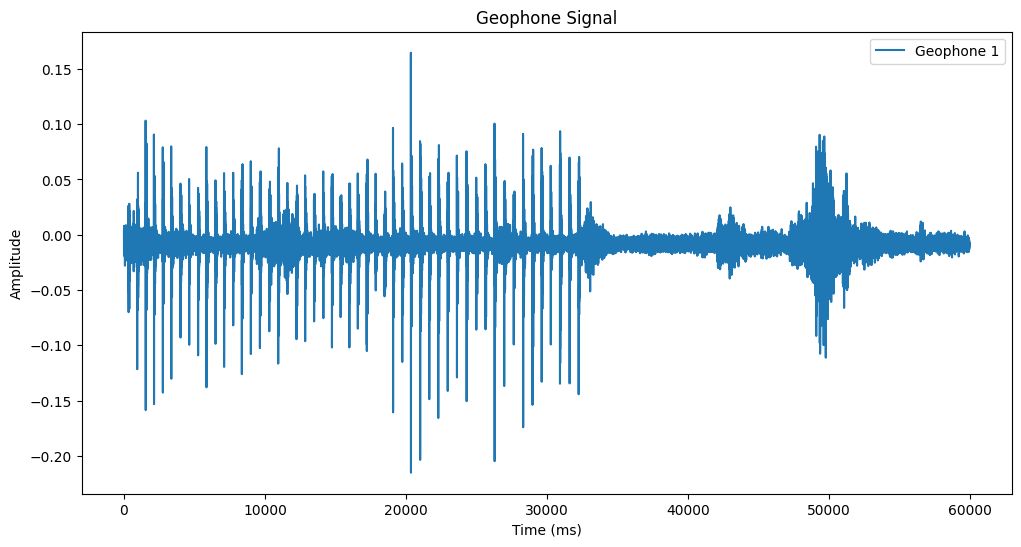

Mean Amplitude: -0.008332369228422334
Max Amplitude: 0.16451
Min Amplitude: -0.21517


In [4]:
# הנחה: עמודות הן גאופונים וזמן
time = np.arange(len(data))  # יצירת ציר זמן

# גרף של עמודת גאופון בודדת (למשל הראשון)
plt.figure(figsize=(12, 6))
plt.plot(time, data.iloc[:, 1], label="Geophone 1")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Geophone Signal")
plt.legend()
plt.show()

# חישוב ערכים סטטיסטיים לגאופון הראשון
amplitude = data.iloc[:, 1]
print("Mean Amplitude:", np.mean(amplitude))
print("Max Amplitude:", np.max(amplitude))
print("Min Amplitude:", np.min(amplitude))


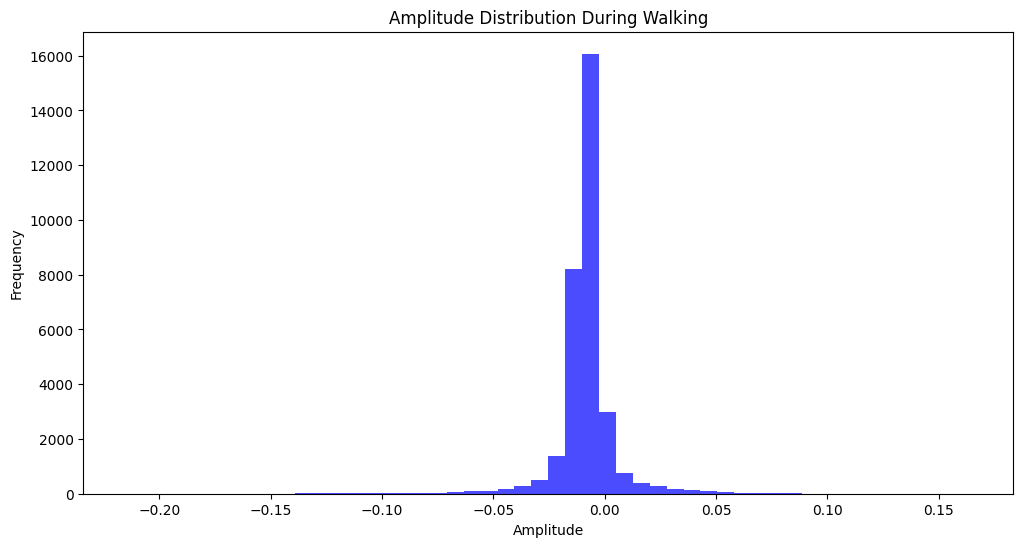

In [5]:
# חיתוך של קטעי ההליכה בלבד (עד 34 שניות)
walking_duration = 32 * 1000  # 34 שניות * 1000 דגימות לשנייה
walking_data = data.iloc[:walking_duration, 1]  # עמודה ראשונה כבדיקה

# היסטוגרמה של המשרעת
plt.figure(figsize=(12, 6))
plt.hist(walking_data, bins=50, color='blue', alpha=0.7)
plt.title("Amplitude Distribution During Walking")
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.show()


In [22]:
# חישוב אחוזונים
p90 = np.percentile(walking_data, 96)  # 90th percentile
p50 = np.percentile(walking_data, 60)  # 50th percentile
print(f"90th Percentile (High Steps): {p90}")
print(f"50th Percentile (Background Noise): {p50}")


90th Percentile (High Steps): 0.011623
50th Percentile (Background Noise): -0.0071526


In [23]:
# הגדרת סיווג
data['Step'] = walking_data > p90 

# אחוז הזמן שמזוהה כצעדים
steps_percentage = data['Step'].mean() * 100
print(f"Steps Detected in {steps_percentage:.2f}% of walking data.")


Steps Detected in 3.99% of walking data.


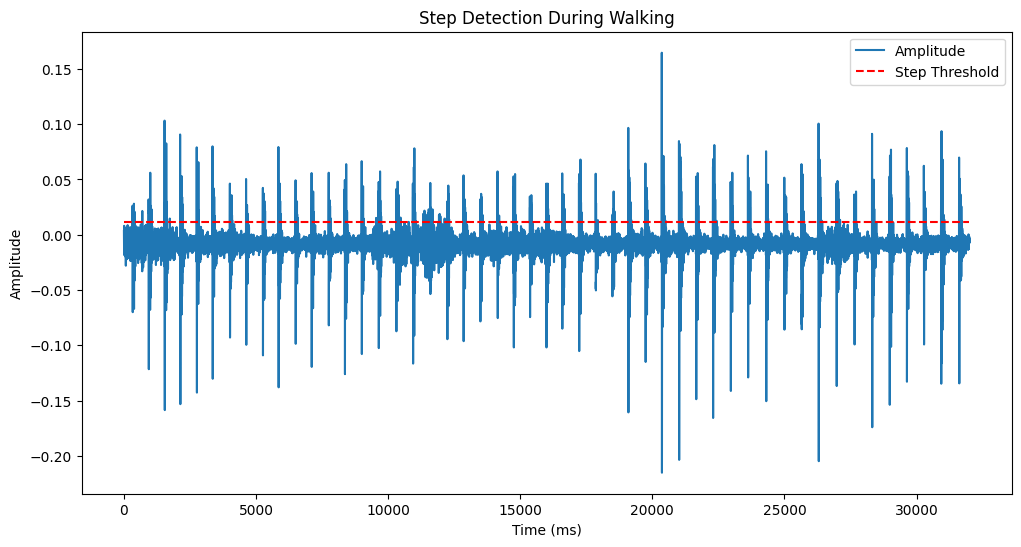

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(walking_data.index, walking_data, label="Amplitude")
plt.hlines(y=p90, xmin=0, xmax=len(walking_data), colors='red', linestyles='dashed', label="Step Threshold")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Step Detection During Walking")
plt.legend()
plt.show()


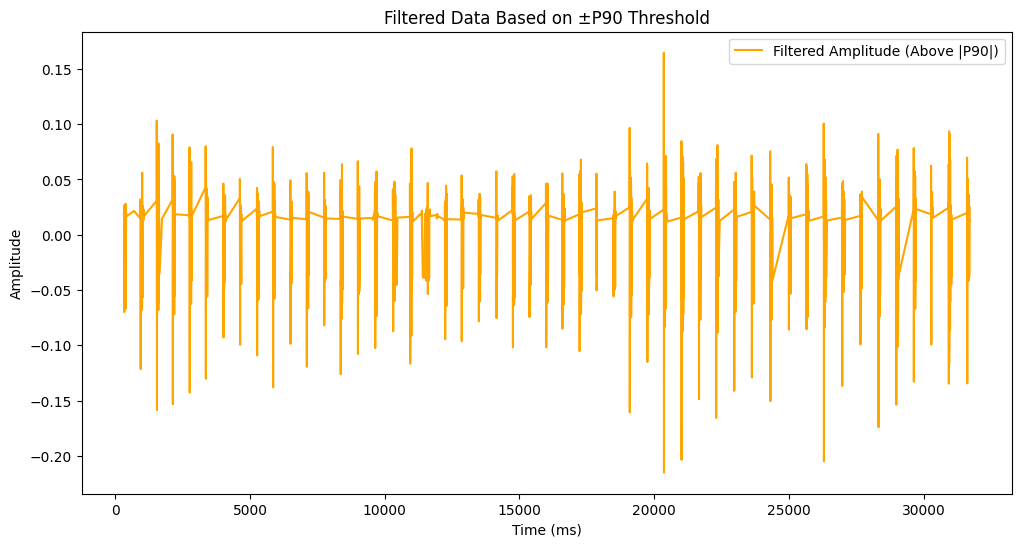

In [25]:
# חישוב ערך מוחלט
abs_walking_data = walking_data.abs()

# שמירת נתונים מעל הסף (בערך מוחלט)
filtered_data = walking_data[(walking_data > p90) | (walking_data < -3*p90)]
# הצגת גרף של הנתונים המסוננים*
plt.figure(figsize=(12, 6))
plt.plot(filtered_data.index, filtered_data, label="Filtered Amplitude (Above |P90|)", color="orange")

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Filtered Data Based on ±P90 Threshold")
plt.legend()
plt.show()


In [27]:
from scipy.signal import find_peaks

# מציאת תנודות חזקות (פיקים)
peaks, _ = find_peaks(filtered_data, height=p90)
peak_intervals = np.diff(peaks)  # הפרשי זמן בין פיקים

# חישוב תדירות (צעדים לשנייה)
sampling_rate = 1000  # נניח דגימה של 1000Hz
step_frequency = sampling_rate / np.mean(peak_intervals)
print(f"Step Frequency: {step_frequency:.2f} steps per second")


Step Frequency: 183.44 steps per second
